# 06 Heckman 选择模型：代码与配图

本 notebook 为 `06_heckman_lec_v4.ipynb` 生成模拟数据、估计结果和配图。核心目标是用企业信贷案例说明：

- 贷款金额可以为 0；
- 贷款利率只在贷款企业中可观测；
- 只用贷款企业估计贷款利率方程可能产生选择性偏误；
- Heckman two-step 通过 IMR 修正选择性观测导致的误差项条件均值偏离。

In [56]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy.stats import norm
from IPython.display import display
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# 创建输出文件夹
os.makedirs("./figs", exist_ok=True)
os.makedirs("./data", exist_ok=True)

# ── 中文字体与全局绘图设置 ─────────────────────────────────────────
# Windows 本地运行时优先使用 SimHei；Linux / macOS 回退到常见 CJK 字体
plt.rcParams["font.sans-serif"] = [
    "SimHei", "Microsoft YaHei", "Noto Sans CJK SC",
    "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "figure.dpi": 160,
})

def save_fig(fig, name, show=True):
    # 同时输出 png 和 svg；png 适合网页和公众号，svg 适合 Quarto HTML
    fig.savefig(f"./figs/{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"./figs/{name}.svg", bbox_inches="tight")
    if show:
        display(fig)
    plt.close(fig)

In [57]:
def simulate_heckman_credit_data(n=3000, seed=20260430, rho=-0.55):
    # 生成企业信贷场景下的 Heckman 选择模型模拟数据
    rng = np.random.default_rng(seed)

    # 抵押能力：0-1 区间变量，数值越大表示可抵押资产比例越高
    collateral = rng.beta(2.0, 2.5, size=n)

    # 银行可得性：可理解为银行网点密度、信贷服务便利度或银企关系便利程度
    bank_access = rng.normal(0, 1, size=n)

    # 企业风险：数值越大，风险越高
    risk = rng.normal(0, 1, size=n)

    # 生成相关误差项：v 影响选择方程，u 影响利率方程
    cov = np.array([[1.0, rho], [rho, 1.0]])
    vu = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n)
    v = vu[:, 0]
    u = vu[:, 1] * 0.85

    # 选择方程：是否获得贷款
    select_index = -0.25 + 1.35 * collateral + 0.85 * bank_access - 0.75 * risk
    loan_star = select_index + v
    loan = (loan_star > 0).astype(int)

    # 结果方程：贷款利率，只在获得贷款时可观测
    rate_latent = 6.2 - 1.15 * collateral + 1.25 * risk + u
    loan_rate = np.where(loan == 1, rate_latent, np.nan)

    # 为了和 04、05 章保持背景统一，也生成贷款金额
    loan_amt = np.where(
        loan == 1,
        np.exp(8.8 + 0.6 * collateral + 0.45 * np.maximum(select_index, -1) + rng.normal(0, 0.35, n)),
        0
    )

    df = pd.DataFrame({
        "collateral": collateral,
        "bank_access": bank_access,
        "risk": risk,
        "select_index_true": select_index,
        "loan_star": loan_star,
        "loan": loan,
        "loan_amt": loan_amt,
        "rate_latent": rate_latent,
        "loan_rate": loan_rate,
        "u_rate": u,
        "v_select": v,
    })

    return df

df = simulate_heckman_credit_data()
df.to_csv("./data/heckman_credit_sim.csv", index=False)

print("样本量:", len(df))
print("获得贷款比例:", round(df["loan"].mean(), 3))
print("贷款利率可观测比例:", round(df["loan_rate"].notna().mean(), 3))
df.head().round(2)

样本量: 3000
获得贷款比例: 0.588
贷款利率可观测比例: 0.588


,collateral,bank_access,risk,select_index_true,loan_star,loan,loan_amt,rate_latent,loan_rate,u_rate,v_select
0,0.38,-0.67,1.08,-1.12,-1.19,0,0.00,7.89,NaN,0.78,-0.07
1,0.39,-0.48,0.34,-0.38,-0.49,0,0.00,6.56,NaN,0.39,-0.10
2,0.15,1.09,-0.84,1.50,2.12,1,12324.11,5.16,5.16,0.18,0.62
3,0.19,-0.02,-1.79,1.34,2.27,1,11551.40,2.97,2.97,-0.77,0.93
4,0.57,-0.51,-0.33,0.34,-0.95,0,0.00,6.70,NaN,1.58,-1.29


In [58]:
# ── 估计 Heckman two-step ─────────────────────────────────────────
# 第一步：用所有样本估计选择方程 Probit
Z_vars = ["collateral", "bank_access", "risk"]
X_vars = ["collateral", "risk"]

Z = sm.add_constant(df[Z_vars])
probit_mod = sm.Probit(df["loan"], Z).fit(disp=False)

# 计算选择指数、选择概率和 IMR
df["xb_select_hat"] = probit_mod.predict(linear=True)
df["p_loan_hat"] = probit_mod.predict()
df["imr_hat"] = norm.pdf(df["xb_select_hat"]) / np.clip(norm.cdf(df["xb_select_hat"]), 1e-8, 1)

# 第二步：只在贷款企业中估计贷款利率方程
obs = df[df["loan"] == 1].copy()

# 直接 OLS：忽略选择性观测
X_naive = sm.add_constant(obs[X_vars])
ols_naive = sm.OLS(obs["loan_rate"], X_naive).fit()

# Heckman two-step：加入 IMR
X_heck = sm.add_constant(obs[X_vars + ["imr_hat"]])
ols_heck = sm.OLS(obs["loan_rate"], X_heck).fit()

# 教学用参照：真实潜在利率在全样本中可见，实际研究中无法观察
X_full = sm.add_constant(df[X_vars])
ols_full = sm.OLS(df["rate_latent"], X_full).fit()

coef_table = pd.DataFrame({
    "true_full_sample_OLS": ols_full.params,
    "naive_observed_OLS": ols_naive.params.reindex(ols_full.params.index),
    "heckman_two_step": ols_heck.params.reindex(ols_full.params.index),
})
coef_table.loc["imr_hat", "heckman_two_step"] = ols_heck.params["imr_hat"]

coef_table.to_csv("./data/heckman_coef_table.csv")

probit_table = pd.DataFrame({
    "coef": probit_mod.params,
    "se": probit_mod.bse,
    "z": probit_mod.tvalues,
    "pvalue": probit_mod.pvalues,
})
probit_table.to_csv("./data/heckman_probit_selection_table.csv")

ols_naive_table = pd.DataFrame({
    "coef": ols_naive.params,
    "se": ols_naive.bse,
    "t": ols_naive.tvalues,
    "pvalue": ols_naive.pvalues,
})
ols_naive_table.to_csv("./data/heckman_naive_ols_table.csv")

ols_heck_table = pd.DataFrame({
    "coef": ols_heck.params,
    "se_naive": ols_heck.bse,
    "t_naive": ols_heck.tvalues,
    "pvalue_naive": ols_heck.pvalues,
})
ols_heck_table.to_csv("./data/heckman_twostep_table.csv")

summary = pd.DataFrame({
    "stat": [
        "n", "share_loan_positive", "rho_true", "probit_llf",
        "naive_beta_collateral", "heckman_beta_collateral", "imr_coef"
    ],
    "value": [
        len(df), df["loan"].mean(), -0.55, probit_mod.llf,
        ols_naive.params["collateral"],
        ols_heck.params["collateral"],
        ols_heck.params["imr_hat"],
    ]
})
summary.to_csv("./data/heckman_summary.csv", index=False)

coef_table.round(3)

,true_full_sample_OLS,naive_observed_OLS,heckman_two_step
const,6.141,5.833,6.169
collateral,-1.052,-0.869,-1.066
risk,1.227,1.139,1.249
imr_hat,NaN,NaN,-0.474


In [59]:
def add_box(ax, xy, text, width=2.8, height=0.72, fc="#F3F8FF", ec="#4C78A8",
            fontsize=12, lw=1.4, dashed=False):
    # 在流程图中添加圆角方框
    x, y = xy
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        fc=fc, ec=ec, lw=lw, linestyle="--" if dashed else "-"
    )
    ax.add_patch(box)
    ax.text(
        x, y, text, ha="center", va="center",
        fontsize=fontsize, color="#111111", linespacing=1.2
    )
    return box

def add_arrow(ax, start, end, color="#333333", lw=1.8):
    # 在流程图中添加箭头
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=14,
        lw=lw, color=color, shrinkA=5, shrinkB=5,
        connectionstyle="arc3"
    ))

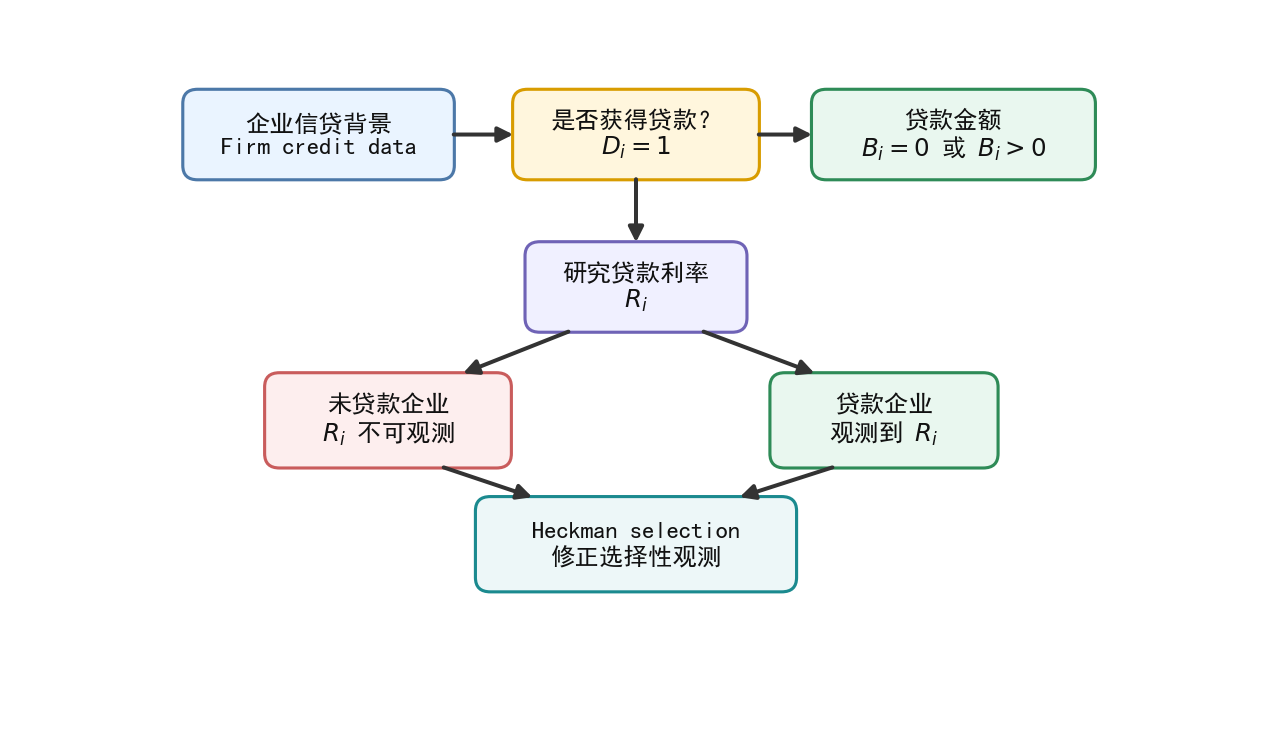

In [60]:
# 图 1：Heckman 选择模型的观测机制
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

# 将横向、纵向间距压缩为原来的 80%
b_firm = add_box(
    ax, (2.44, 5.0), "企业信贷背景\nFirm credit data",
    width=2.15, height=0.72, fc="#EAF4FF", ec="#4C78A8", fontsize=11
)
b_select = add_box(
    ax, (5.0, 5.0), "是否获得贷款？\n$D_i=1$",
    width=1.95, height=0.72, fc="#FFF6DD", ec="#D89C00", fontsize=11
)
b_amt = add_box(
    ax, (7.56, 5.0), "贷款金额\n$B_i=0$ 或 $B_i>0$",
    width=2.25, height=0.72, fc="#E9F7EF", ec="#2E8B57", fontsize=11
)
b_rate = add_box(
    ax, (5.0, 3.72), "研究贷款利率\n$R_i$",
    width=1.75, height=0.72, fc="#F0F0FF", ec="#6F63B6", fontsize=11
)
b_noloan = add_box(
    ax, (3.0, 2.60), "未贷款企业\n$R_i$ 不可观测",
    width=1.95, height=0.76, fc="#FDEEEE", ec="#C95C5C", fontsize=11
)
b_loaned = add_box(
    ax, (7.0, 2.60), "贷款企业\n观测到 $R_i$",
    width=1.8, height=0.76, fc="#E9F7EF", ec="#2E8B57", fontsize=11
)
b_heck = add_box(
    ax, (5.0, 1.56), "Heckman selection\n修正选择性观测",
    width=2.55, height=0.76, fc="#EDF7F8", ec="#1B8A8F", fontsize=11
)

def anchor(box, xfrac, yfrac, dx=0.0, dy=0.0):
    return (
        box.get_x() + box.get_width() * xfrac + dx,
        box.get_y() + box.get_height() * yfrac + dy
    )

def add_arrow_tight(ax, start, end, color="#333333", lw=1.8):
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=14,
        lw=lw, color=color, shrinkA=0, shrinkB=0,
        connectionstyle="arc3"
    ))

# 箭头尽量贴近方框边缘
gap = 0.015
add_arrow_tight(ax, anchor(b_firm, 1.0, 0.5, dx=gap), anchor(b_select, 0.0, 0.5, dx=-gap))
add_arrow_tight(ax, anchor(b_select, 1.0, 0.5, dx=gap), anchor(b_amt, 0.0, 0.5, dx=-gap))
add_arrow_tight(ax, anchor(b_select, 0.5, 0.0, dy=-gap), anchor(b_rate, 0.5, 1.0, dy=gap))

add_arrow_tight(ax, anchor(b_rate, 0.20, 0.0, dx=-0.02, dy=-gap), anchor(b_noloan, 0.80, 1.0, dx=0.02, dy=gap))
add_arrow_tight(ax, anchor(b_rate, 0.80, 0.0, dx=0.02, dy=-gap), anchor(b_loaned, 0.20, 1.0, dx=-0.02, dy=gap))

add_arrow_tight(ax, anchor(b_noloan, 0.72, 0.0, dx=0.02, dy=-gap), anchor(b_heck, 0.18, 1.0, dx=-0.02, dy=gap))
add_arrow_tight(ax, anchor(b_loaned, 0.28, 0.0, dx=-0.02, dy=-gap), anchor(b_heck, 0.82, 1.0, dx=0.02, dy=gap))

# ax.text(
#     0.2, 0.1,
#     "核心区别：贷款金额可以为 0；未贷款企业的贷款利率不是 0，而是 missing。",
#     fontsize=11, color="#333333"
# )

save_fig(fig, "limit_dep_heckman_fig01_selection_mechanism")

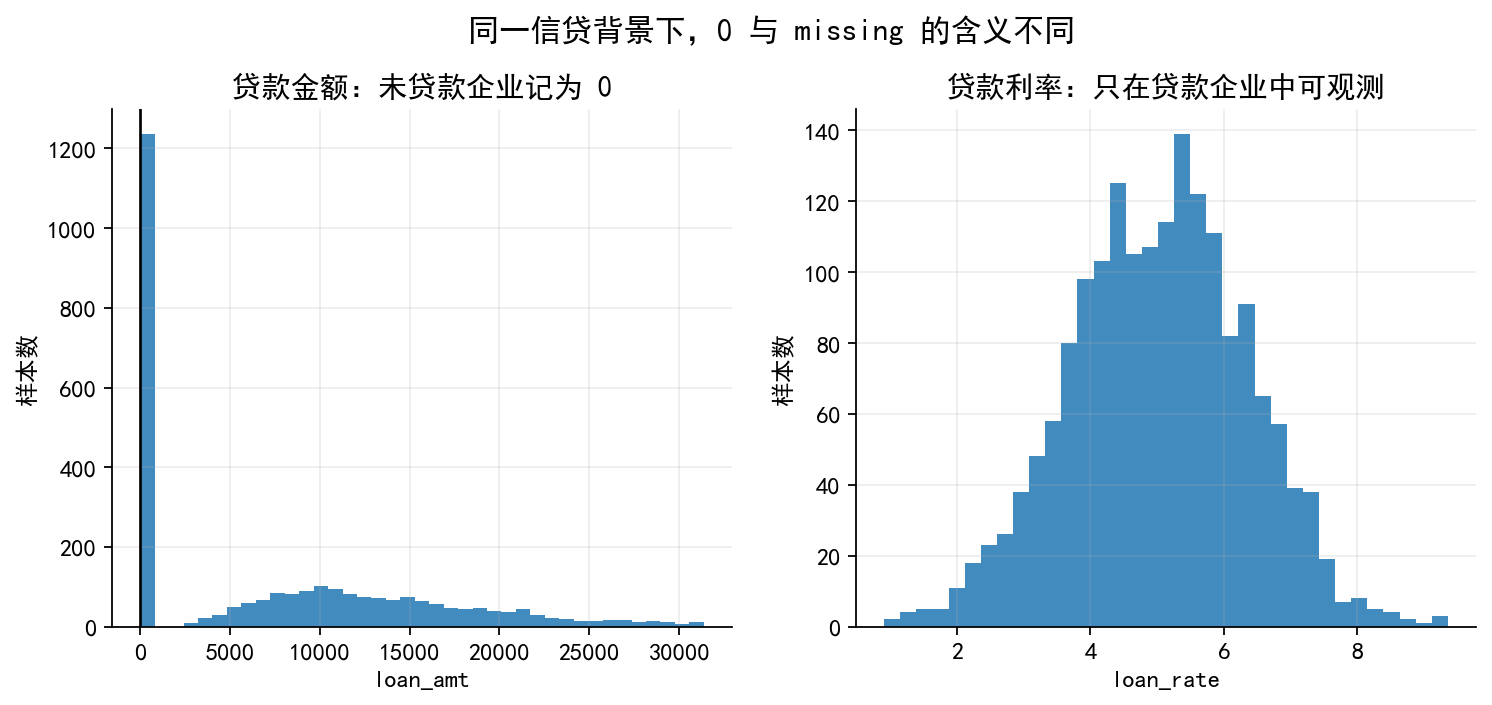

In [61]:
# 图 2：贷款金额中的 0 与贷款利率中的 missing
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
bins = np.linspace(0, np.percentile(df["loan_amt"], 95), 40)
ax.hist(df["loan_amt"], bins=bins, alpha=0.85)
ax.axvline(0, color="k", lw=1.2)
ax.set_title("贷款金额：未贷款企业记为 0")
ax.set_xlabel("loan_amt")
ax.set_ylabel("样本数")

ax = axes[1]
ax.hist(obs["loan_rate"], bins=35, alpha=0.85)
ax.set_title("贷款利率：只在贷款企业中可观测")
ax.set_xlabel("loan_rate")
ax.set_ylabel("样本数")

fig.suptitle("同一信贷背景下，0 与 missing 的含义不同", fontsize=14, y=1.02)
save_fig(fig, "limit_dep_heckman_fig02_zero_vs_missing")

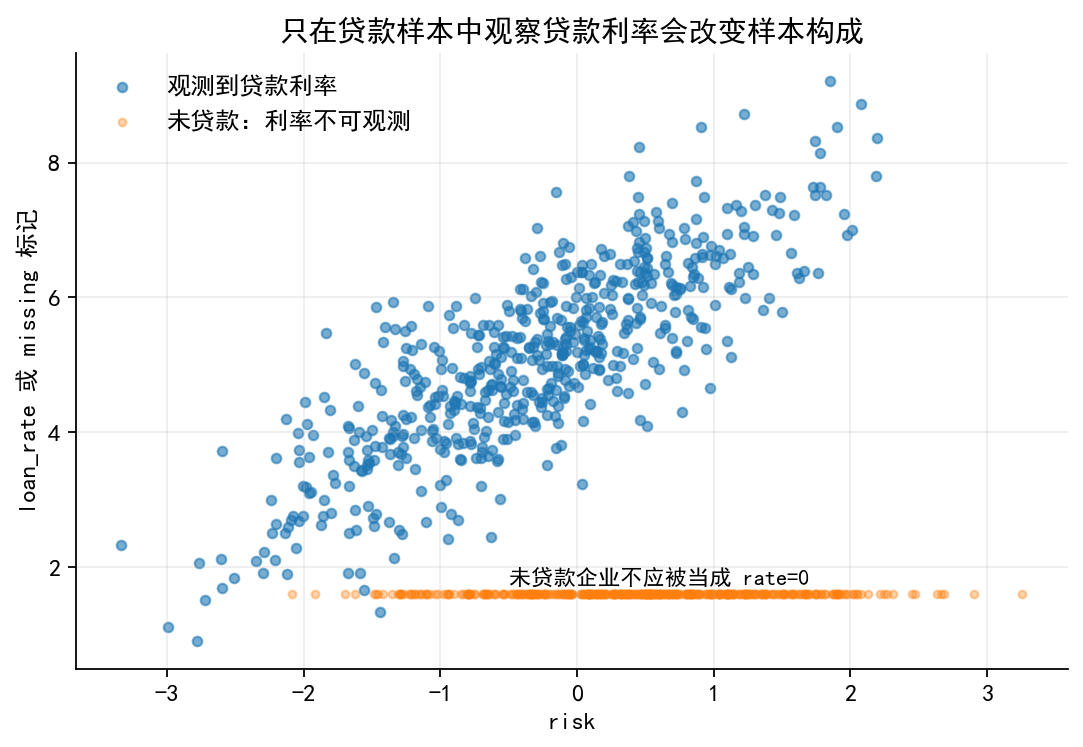

In [62]:
# 图 3：选择性观测与样本构成
fig, ax = plt.subplots(figsize=(8, 5.0))

sample = df.sample(1000, random_state=12)
ax.scatter(
    sample["risk"], sample["loan_rate"].fillna(np.nan),
    s=18, alpha=0.6, label="观测到贷款利率"
)
ax.scatter(
    sample.loc[sample["loan"] == 0, "risk"],
    np.full((sample["loan"] == 0).sum(), 1.6),
    s=12, alpha=0.35, label="未贷款：利率不可观测"
)

ax.set_xlabel("risk")
ax.set_ylabel("loan_rate 或 missing 标记")
ax.set_title("只在贷款样本中观察贷款利率会改变样本构成")
ax.legend(frameon=False)
ax.text(-0.5, 1.75, "未贷款企业不应被当成 rate=0", fontsize=10)

save_fig(fig, "limit_dep_heckman_fig03_selected_sample_bias")

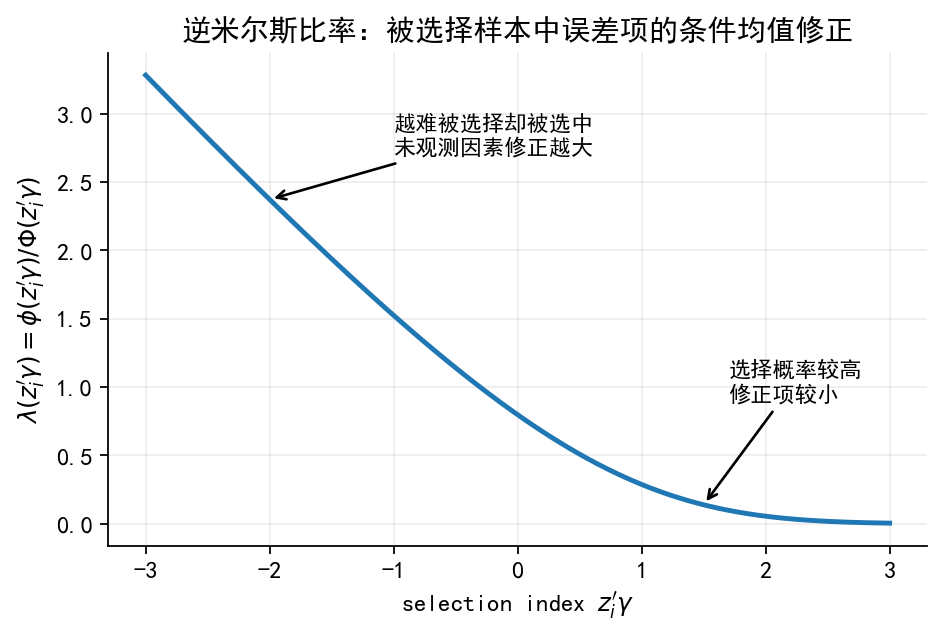

In [63]:
# 图 4：IMR 曲线
a = np.linspace(-3, 3, 300)
lambda_pos = norm.pdf(a) / norm.cdf(a)

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(a, lambda_pos, lw=2.2)
ax.set_xlabel(r"selection index $z_i'\gamma$")
ax.set_ylabel(r"$\lambda(z_i'\gamma)=\phi(z_i'\gamma)/\Phi(z_i'\gamma)$")
ax.set_title("逆米尔斯比率：被选择样本中误差项的条件均值修正")

ax.annotate(
    "越难被选择却被选中\n未观测因素修正越大",
    xy=(-2, norm.pdf(-2) / norm.cdf(-2)),
    xytext=(-1, 2.7),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10
)
ax.annotate(
    "选择概率较高\n修正项较小",
    xy=(1.5, norm.pdf(1.5) / norm.cdf(1.5)),
    xytext=(1.7, 0.9),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10
)

save_fig(fig, "limit_dep_heckman_fig04_imr_curve")

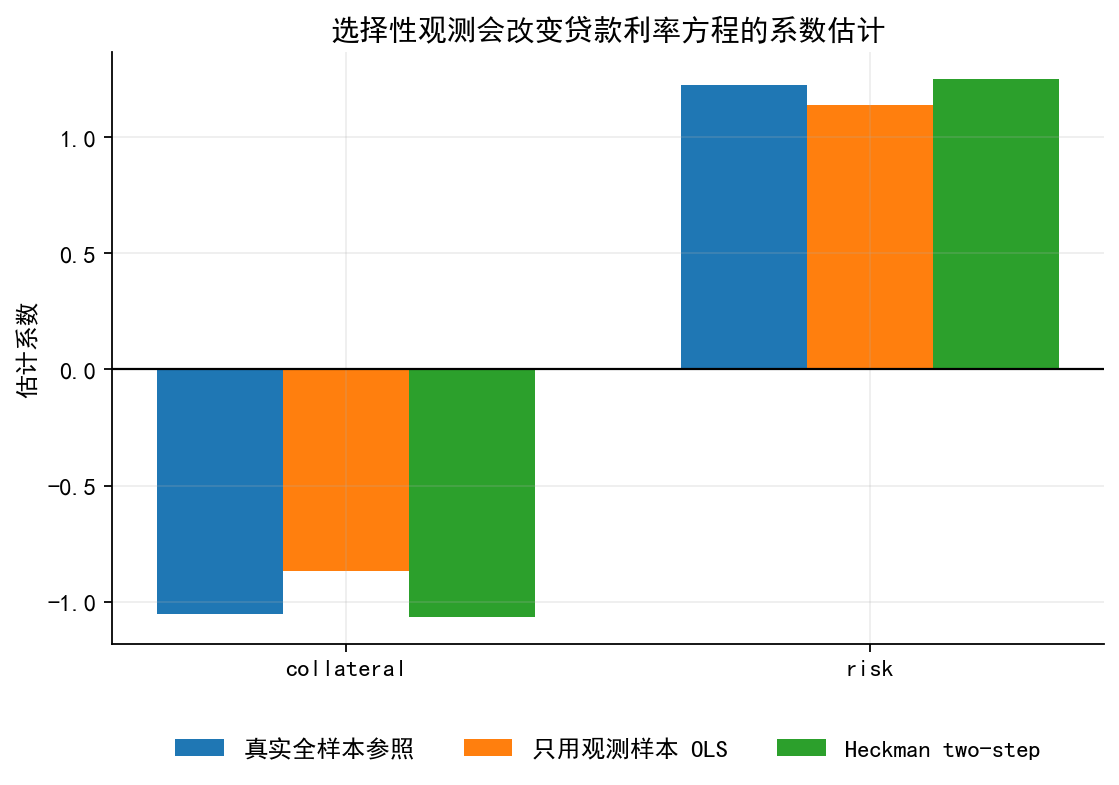

In [64]:
# 图 5：直接 OLS 与 Heckman two-step 的系数比较
coef_comp = pd.DataFrame({
    "变量": ["collateral", "risk"],
    "真实全样本参照": [ols_full.params["collateral"], ols_full.params["risk"]],
    "只用观测样本 OLS": [ols_naive.params["collateral"], ols_naive.params["risk"]],
    "Heckman two-step": [ols_heck.params["collateral"], ols_heck.params["risk"]],
})

fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(coef_comp))
w = 0.24

ax.bar(x - w, coef_comp["真实全样本参照"], width=w, label="真实全样本参照")
ax.bar(x, coef_comp["只用观测样本 OLS"], width=w, label="只用观测样本 OLS")
ax.bar(x + w, coef_comp["Heckman two-step"], width=w, label="Heckman two-step")

ax.axhline(0, color="k", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(coef_comp["变量"])
ax.set_ylabel("估计系数")
ax.set_title("选择性观测会改变贷款利率方程的系数估计")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))

save_fig(fig, "limit_dep_heckman_fig05_coef_comparison")

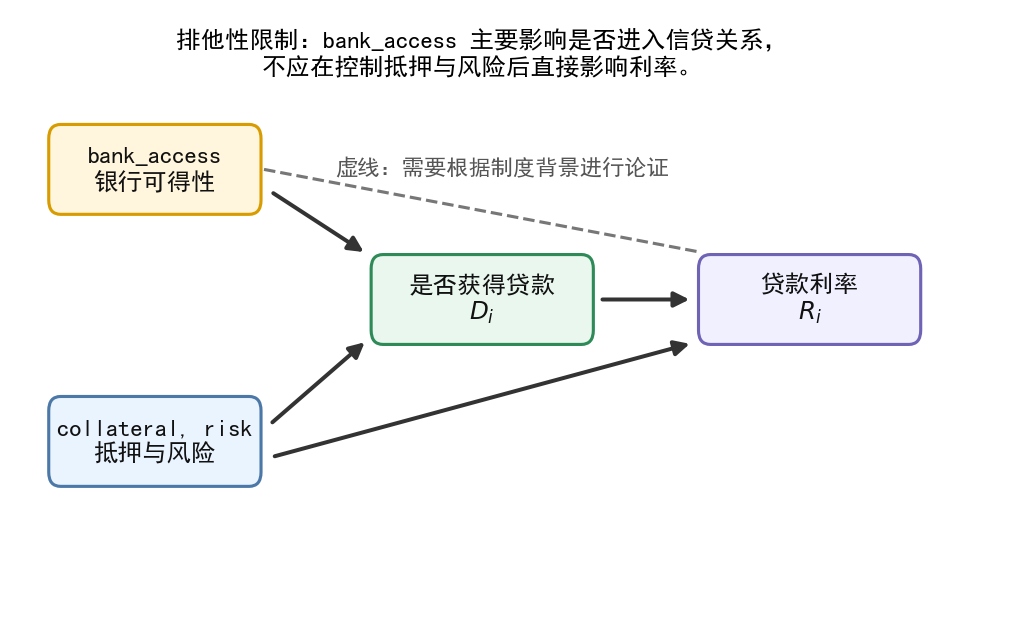

In [65]:
# 图 6：排他性变量的机制解释
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

add_box(ax, (1.4, 3.7), "bank_access\n银行可得性", width=2.1, fc="#FFF6DD", ec="#D89C00", fontsize=11)
add_box(ax, (1.4, 1.4), "collateral, risk\n抵押与风险", width=2.1, fc="#EAF4FF", ec="#4C78A8", fontsize=11)
add_box(ax, (4.7, 2.6), "是否获得贷款\n$D_i$", width=2.2, fc="#E9F7EF", ec="#2E8B57", fontsize=11)
add_box(ax, (8.0, 2.6), "贷款利率\n$R_i$", width=2.2, fc="#F0F0FF", ec="#6F63B6", fontsize=11)

add_arrow(ax, (2.5, 3.55), (3.6, 2.95))
add_arrow(ax, (2.5, 1.5), (3.6, 2.3))
add_arrow(ax, (5.8, 2.6), (6.9, 2.6))
add_arrow(ax, (2.5, 1.25), (6.9, 2.25))

# 虚线表示潜在违反排他性限制的直接通道
ax.plot([2.5, 6.9], [3.7, 3.0], color="#777", lw=1.4, ls="--")

ax.text(
    4.7, 4.5,
    "排他性限制：bank_access 主要影响是否进入信贷关系，\n不应在控制抵押与风险后直接影响利率。",
    ha="center", fontsize=11
)
ax.text(
    4.9, 3.65,
    "虚线：需要根据制度背景进行论证",
    ha="center", fontsize=10, color="#555"
)

save_fig(fig, "limit_dep_heckman_fig06_exclusion_restriction")

## 输出文件清单

本 notebook 会输出：

- `./data/heckman_credit_sim.csv`
- `./data/heckman_coef_table.csv`
- `./data/heckman_probit_selection_table.csv`
- `./data/heckman_naive_ols_table.csv`
- `./data/heckman_twostep_table.csv`
- `./data/heckman_summary.csv`
- `./figs/limit_dep_heckman_fig01_selection_mechanism.png`
- `./figs/limit_dep_heckman_fig02_zero_vs_missing.png`
- `./figs/limit_dep_heckman_fig03_selected_sample_bias.png`
- `./figs/limit_dep_heckman_fig04_imr_curve.png`
- `./figs/limit_dep_heckman_fig05_coef_comparison.png`
- `./figs/limit_dep_heckman_fig06_exclusion_restriction.png`

每张图同时输出 `.png` 和 `.svg` 两种格式。